In [4]:
!pip install tensorflow


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import datasets, models, layers
from sklearn.metrics import confusion_matrix

Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Testing data shape: (10000, 28, 28), Testing labels shape: (10000,)


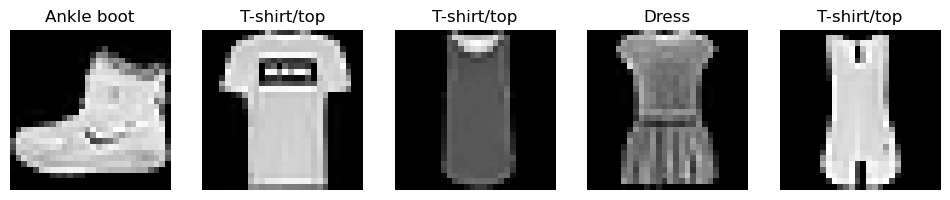

In [15]:
# Load the dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Define the class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

# Display the first 5 images from the training set

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [16]:
# Normalize pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0



In [17]:
# Build the base model
base_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)), # Flattens the 28x28 images into a 1D array of 784 pixels
    layers.Dense(128, activation='relu'), # Hidden layer 1
    layers.Dense(64, activation='relu'),  # Hidden layer 2
    layers.Dense(10, activation='softmax') # Output layer (10 classes)
])

# Compile the model
base_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Train for 10 epochs with a validation split
print("Training Base Model:")
base_history = base_model.fit(X_train, y_train, epochs=10, validation_split=0.2)

C:\Users\Diksha\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Base Model:
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8169 - loss: 0.5164 - val_accuracy: 0.8553 - val_loss: 0.4097
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8619 - loss: 0.3802 - val_accuracy: 0.8599 - val_loss: 0.3834
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8751 - loss: 0.3404 - val_accuracy: 0.8598 - val_loss: 0.3786
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8824 - loss: 0.3160 - val_accuracy: 0.8762 - val_loss: 0.3376
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8882 - loss: 0.2975 - val_accuracy: 0.8682 - val_loss: 0.3762
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8941 - loss: 0.2815 - val_accuracy: 0.8823 - val_loss: 0.3251
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8987 - loss: 0.2708 - val_accuracy: 0.8677 - val_loss: 0.3572
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accur

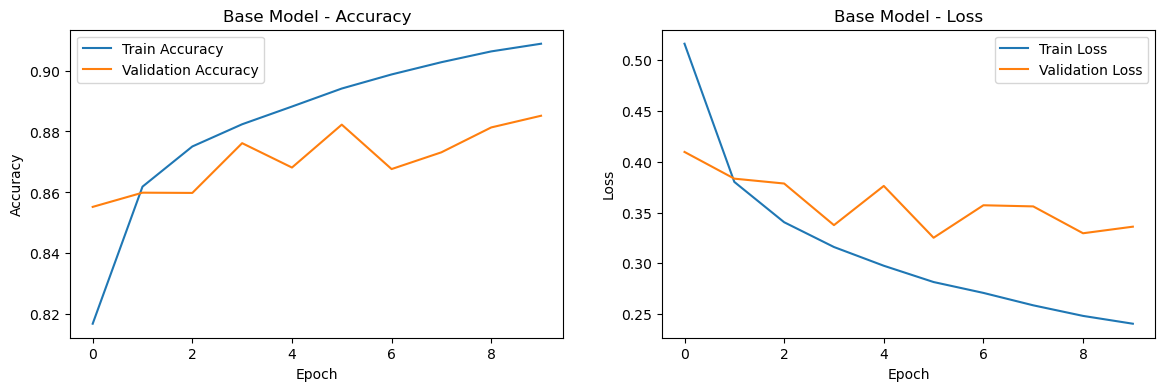

In [18]:
# 6. Plot the loss & accuracy curves
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Plot Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Plot Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.show()

plot_history(base_history, "Base Model")

Training Dropout Model:
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7624 - loss: 0.6605 - val_accuracy: 0.8432 - val_loss: 0.4297
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8309 - loss: 0.4730 - val_accuracy: 0.8544 - val_loss: 0.3938
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8438 - loss: 0.4314 - val_accuracy: 0.8622 - val_loss: 0.3784
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8508 - loss: 0.4119 - val_accuracy: 0.8627 - val_loss: 0.3699
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8587 - loss: 0.3903 - val_accuracy: 0.8633 - val_loss: 0.3851
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8634 - loss: 0.3813 - val_accuracy: 0.8752 - val_loss: 0.3445
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8655 - loss: 0.3692 - val_accuracy: 0.8758 - val_loss: 0.3402
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - ac

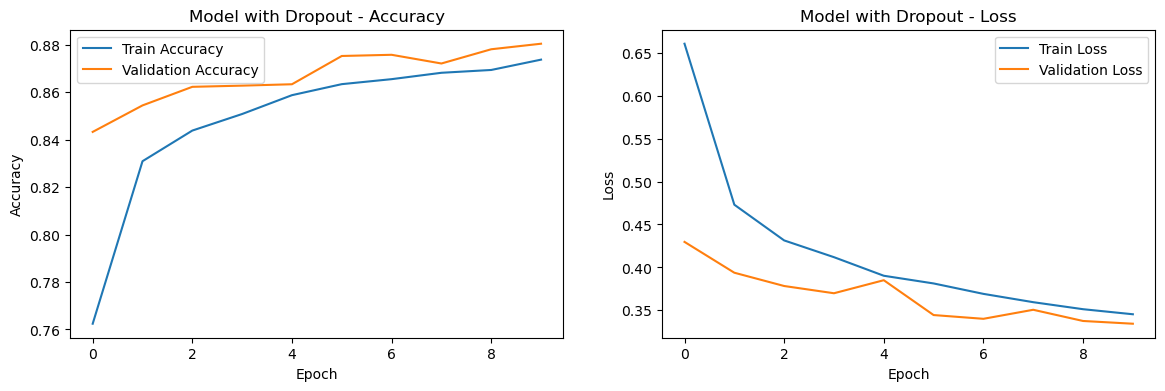

In [19]:
# 7. Add Dropout and compare — does it reduce overfitting.

# Build model with Dropout
dropout_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Drops 30% of neurons
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Drops 30% of neurons
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Training Dropout Model:")
dropout_history = dropout_model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Plot to compare
plot_history(dropout_history, "Model with Dropout")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


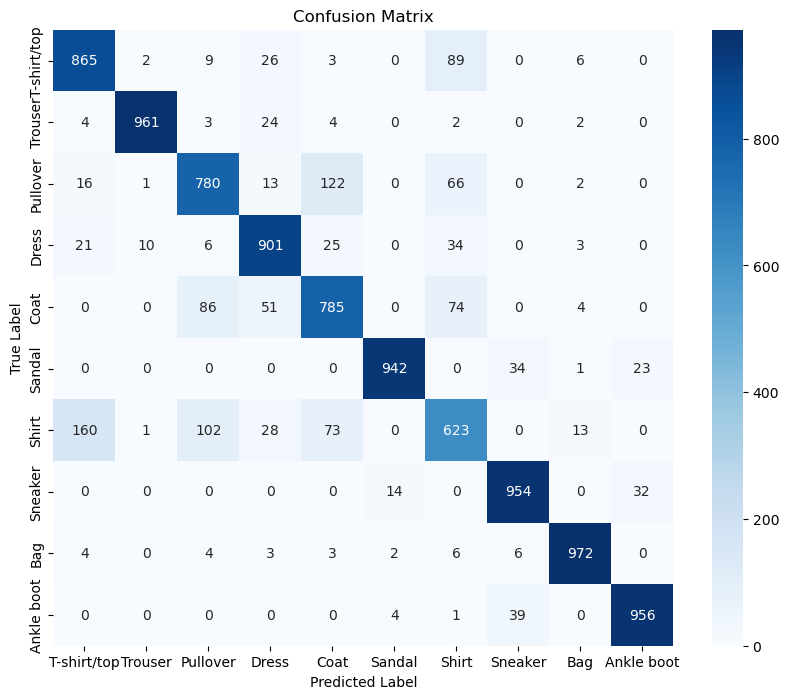

In [20]:
# Make predictions on the test set
y_pred = dropout_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Get the index of the highest probability

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

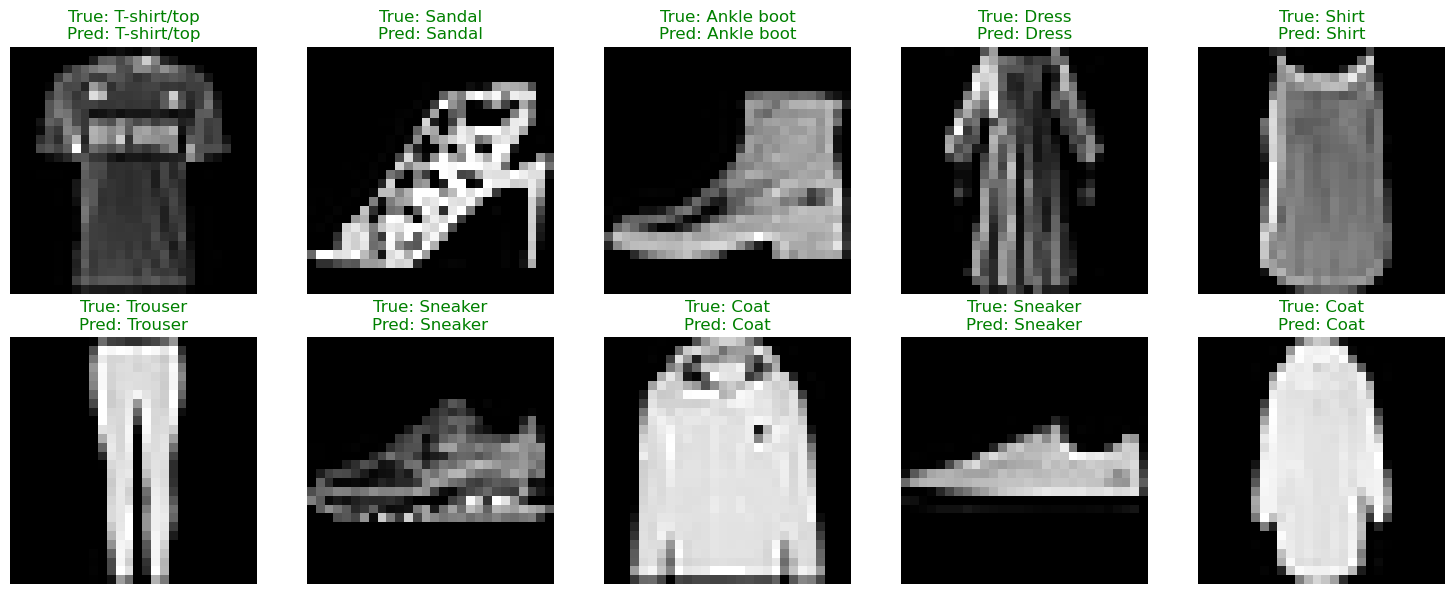

In [24]:
#  make predication on 10 images
# Select 10 random images from the test set
indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx], cmap='grey')
    
    true_label = class_names[y_test[idx]]
    predicted_label = class_names[y_pred_classes[idx]]
    
    # Color the title green if correct, red if incorrect
    color = 'green' if true_label == predicted_label else 'red'
    
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')
    
plt.tight_layout()
plt.show()